In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
RUTA_DATOS = '../Data/Mall_Customers.csv'
SEED = 123 # Semilla ya que k-means es estocástico

In [5]:
mall = pd.read_csv(RUTA_DATOS)

In [6]:
mall

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [10]:
variables = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
mall_datos = mall[variables]

mall_datos.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [13]:
escalador = StandardScaler()
mall_escalado = escalador.fit_transform(mall_datos)

In [16]:
## Cuantos cluster (k)? Utilizmaos el método del codo

wss = []
valores_k = range(1,11)
for k in valores_k:
    modelo = KMeans(n_clusters=k, n_init=25, random_state=SEED)
    modelo.fit(mall_escalado)
    wss.append(modelo.inertia_) # inertia_ es lo mismo que wss

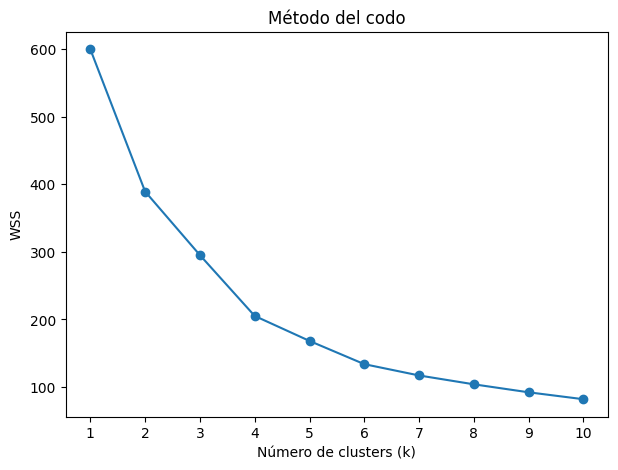

In [17]:
plt.figure(figsize=(7, 5))
plt.plot(valores_k, wss, marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("WSS")
plt.xticks(list(valores_k))
plt.show()